# Earthquake Alert Dataset Exploratory Data Analysis (EDA)
This notebook performs a comprehensive EDA on the `earthquake_alert_balanced_dataset.csv` file.

## 1. Import Libraries for Data Analysis

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")

## 2. Load CSV Data into a DataFrame

In [6]:
file_path = "earthquake_alert_balanced_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


## 3. Inspect Data Structure, Shape, and Missing Values

In [7]:
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Size: {df.size}")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1300, 6)
Dataset Size: 7800

Missing Values:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Data Types:
magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert            str
dtype: object


## 3.1 Check for Duplicate Values

In [8]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate Rows (first 5):")
    display(df[df.duplicated()].head())

Number of duplicate rows: 44

Duplicate Rows (first 5):


,magnitude,depth,cdi,mmi,sig,alert
327,6.50,20.0,0.0,4.0,-118.0,green
332,6.50,10.0,0.0,5.0,-118.0,green
373,6.50,20.0,0.0,6.0,-118.0,green
540,6.91,16.0,7.0,7.0,-13.0,orange
582,7.02,32.0,8.0,7.0,62.0,orange


## 4. Summary Statistics and Data Distribution

In [10]:
df.describe()

,magnitude,depth,cdi,mmi,sig
count,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000
mean,7.060796,51.316879,6.960191,6.917994,-10.404459
std,0.423277,105.899870,2.245138,1.363892,62.370941
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.710000,12.000000,6.000000,6.000000,-55.000000
50%,6.995000,19.000000,8.000000,7.000000,-8.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


## 5. Visualizing Numerical Distributions

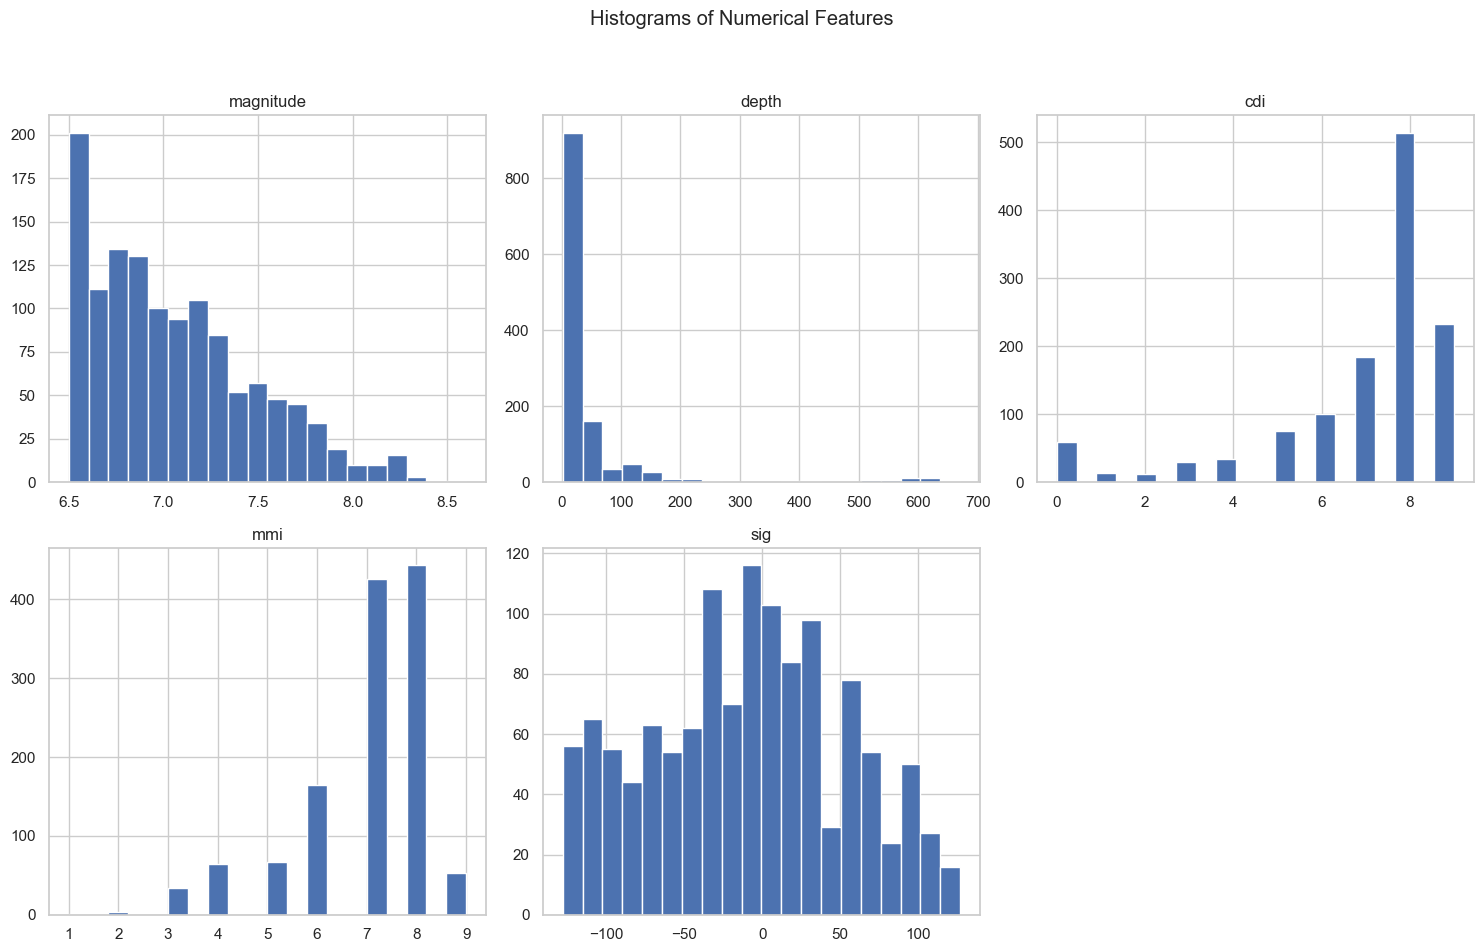

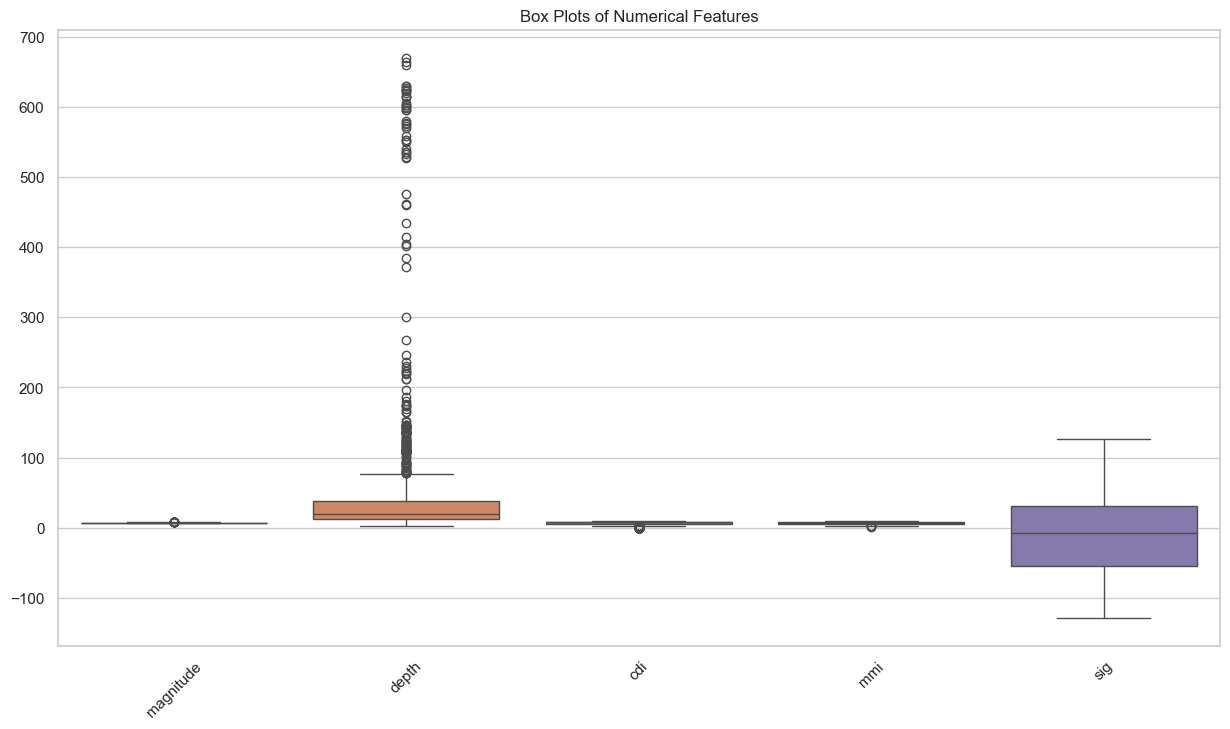

In [11]:
# Select numerical columns for distribution plotting
num_cols = df.select_dtypes(include=[np.number]).columns

# Plot histograms for each numerical column
df[num_cols].hist(bins=20, figsize=(15, 10), layout=(len(num_cols)//3 + 1, 3))
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Box Plots of Numerical Features")
plt.show()

## 6. Analyzing Feature Correlations

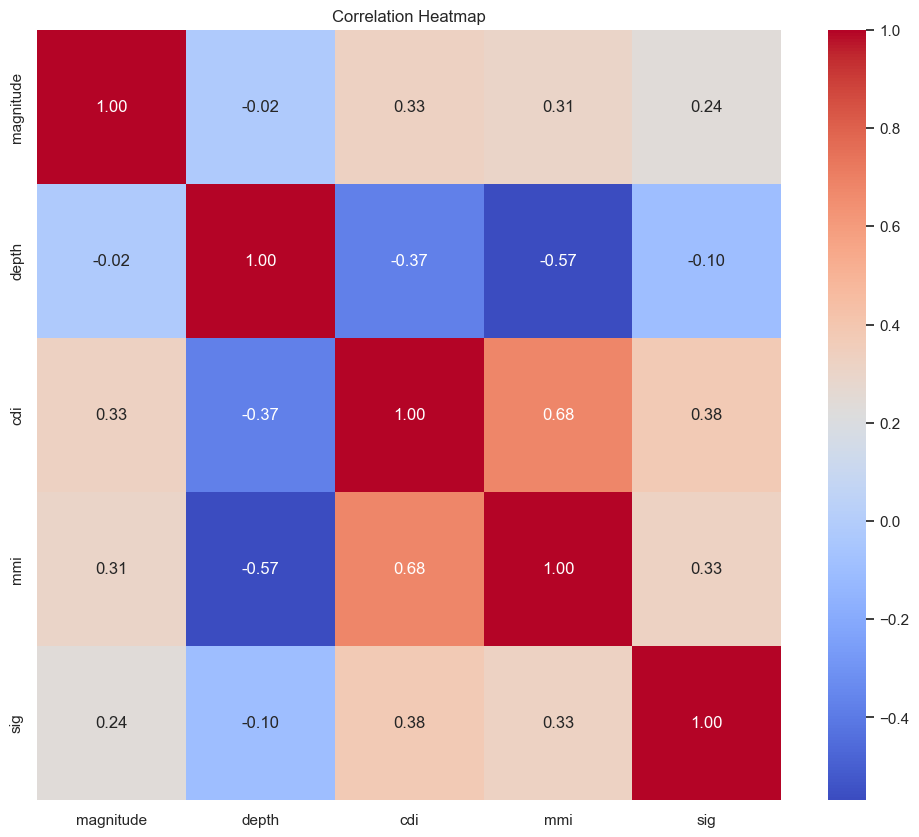

In [12]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()